In [1]:
from graphviz import Digraph
import random
import math
from typing import Callable
import torch

In [103]:
class Expression:
    def __init__(self, value: float = 0.0):
        self.value = value
        self.grad = 0.0
        self.operands = []
        self.op = ''
        self.backward = lambda: None
        self.forward = lambda: None
        self.tensor = torch.Tensor([value]).double()
        self.tensor.requires_grad = True

    def unary(self, op: str, backward: Callable[[], None], forward: Callable[[], None], operand):
        self.op = op
        self.backward = backward        
        self.forward = forward
        self.forward()
        self.operands = [operand]        

    def binary(self, op: str, backward: Callable[[], None], forward: Callable[[], None], operand0, operand1):
        self.op = op
        self.backward = backward        
        self.forward = forward
        self.forward()
        self.operands = [operand0, operand1]        

    def multiple(self, op: str, backward: Callable[[], None], forward: Callable[[], None], operands):
        self.op = op
        self.backward = backward        
        self.forward = forward
        self.forward()
        self.operands = operands

    def __add__(self, other):
        result = Expression()                
        def backward():
            self.grad += result.grad
            other.grad += result.grad                                
        def forward():
            self.forward()
            other.forward()
            result.value = self.value + other.value   
            result.tensor = self.tensor + other.tensor
            result.tensor.retain_grad();
        result.binary(
            '+',
            backward,
            forward,
            self,
            other
        )
        return result

    def __sub__(self, other):
        result = Expression()                
        def backward():
            self.grad += result.grad
            other.grad += -result.grad                                
        def forward():
            self.forward()
            other.forward()
            result.value = self.value - other.value   
            result.tensor = self.tensor - other.tensor
            result.tensor.retain_grad();
        result.binary(
            '-',
            backward,
            forward,
            self,
            other
        )
        return result

    def __mul__(self, other):
        result = Expression()        
        def backward():
            self.grad += other.value * result.grad
            other.grad += self.value * result.grad                    
        def forward():
            self.forward()
            other.forward()
            result.value = self.value * other.value        
            result.tensor = self.tensor * other.tensor
            result.tensor.retain_grad();
        result.binary(
            '*',
            backward,
            forward,
            self,
            other
        )
        return result

    def __truediv__(self, other):
        result = Expression()        
        def backward():
            self.grad += (1.0 / other.value) * result.grad
            other.grad += (-self.value / (other.value * other.value)) * result.grad                    
        def forward():
            self.forward()
            other.forward()
            result.value = self.value / other.value
            result.tensor = self.tensor / other.tensor
            result.tensor.retain_grad();
        result.binary(
            '/',
            backward,
            forward,
            self,
            other
        )
        return result

    def __pow__(self, other):
        result = Expression()        
        def backward():
            self.grad += other.value * math.pow(self.value, other.value - 1) * result.grad
            # print(self.value, other.value)
            # print(math.pow(self.value, other.value))
            # print(math.log(self.value))
            other.grad += math.pow(self.value, other.value) * math.log(self.value) * result.grad                    
        def forward():
            self.forward()
            other.forward()
            result.value = math.pow(self.value, other.value)  
            result.tensor = torch.Tensor.pow(self.tensor, other.tensor);
            result.tensor.retain_grad();
        result.binary(
            '**',
            backward,
            forward,
            self,
            other
        )
        return result

    def exp(self):
        result = Expression()        
        def backward():
            self.grad += math.exp(self.value) * result.grad                    
        def forward():
            self.forward()            
            result.value = math.exp(self.value)   
            result.tensor = torch.Tensor.exp(self.tensor);
            result.tensor.retain_grad();     
        result.unary(
            'exp',
            backward,
            forward,
            self,            
        )
        return result

    def sqr(self):
        result = Expression()        
        def backward():
            self.grad += 2 * self.value * result.grad                    
        def forward():
            self.forward()            
            result.value = self.value * self.value
            result.tensor = torch.Tensor.pow(self.tensor, 2);
            result.tensor.retain_grad();     
        result.unary(
            'sqr',
            backward,
            forward,
            self,            
        )
        return result

    def tanh(self):
        result = Expression()        
        def backward():
            self.grad += (1.0 - math.pow(math.tanh(self.value), 2)) * result.grad        
        def forward():
            self.forward()            
            result.value = math.tanh(self.value)   
            result.tensor = torch.Tensor.tanh(self.tensor);
            result.tensor.retain_grad();          
        result.unary(
            'exp',
            backward,
            forward,
            self,            
        )
        return result
    
    def sum(operands):
        result = Expression()                
        def backward():
            for o in operands:
                o.grad += result.grad            
        def forward():
            for o in operands:
                o.forward()
            result.value = sum([o.value for o in operands])
            result.tensor = sum([o.tensor for o in operands])
            result.tensor.retain_grad();
        result.multiple(
            'sum',
            backward,
            forward,
            operands
        )
        return result

class neuron:
    def __init__(self, inputs: int):
        self.ws = [Expression(random.uniform(-1.0, 1.0)) for i in range(inputs)]
        self.b = Expression(random.uniform(-0.5, 0.5))
    def parameters(self):
        return self.ws + [self.b]
    def __call__(self, inputs: list[Expression]):
        weighteds = [w * i for w, i in zip(self.ws, inputs)]
        sum_and_viased = Expression.sum(weighteds + [self.b])
        return sum_and_viased.tanh()        

class layer:
    def __init__(self, inputs: int, outs: int):
        self.neurons = [neuron(inputs) for i in range(outs)]
    def parameters(self):
        result = []
        for n in self.neurons:
            result += n.parameters()
        return result        
    def __call__(self, inputs: list[Expression]):
        return [n(inputs) for n in self.neurons]

class mlp:
    def __init__(self, inputs: int, outs: int):
        self.layers = []
        for out in outs:
            self.layers.append(layer(inputs, out))
            inputs = out
    def parameters(self):
        result = []
        for l in self.layers:
            result += l.parameters()
        return result        
    def __call__(self, inputs: list[Expression]):        
        for l in self.layers:
            inputs = l(inputs)
        return Expression.sum(inputs)

def collect_tsorted(root : Expression):
    result = []
    def tsort(e: Expression):
        if e not in result:
            result.append(e)
            for o in e.operands:
                tsort(o)
    tsort(root)
    return result    

def backward(root : Expression):
    result = collect_tsorted(root)
    for e in result:
        e.grad = 0.0
    root.grad = 1
    for e in result:
        e.backward()
    result[0].tensor.backward()

def test_grad(root: Expression):
    result = collect_tsorted(root)
    noops = [e for e in result if not e.op]    
    original_values = [e.value for e in noops]
    backward(root)
    original_result = root.value    
    original_grads = [e.grad for e in noops]
    estimated_grads = []    
    epsilon = 0.00001
    for i in range(len(noops)):        
        noops[i].value = original_values[i] + epsilon
        root.forward()        
        estimated_grads.append((root.value - original_result) / epsilon)
        noops[i].value = original_values[i]
    torch_grads = []
    for i in range(len(noops)):            
        torch_grads.append(noops[i].tensor.grad.item())
    print("original", original_grads)
    print("estimated", estimated_grads)
    print("torch", torch_grads)

# orphan nodes are not matter
def create_random_graph(depth: int):
    nodes = [Expression(random.randint(1, 3)) for i in range(depth)]
    depth -= 1
    while depth > 0:
        level = []
        for i in range(depth):
            kind = random.randint(1, 8)
            random.shuffle(nodes)
            x = nodes[0]
            y = nodes[1]
            if kind == 1:
                level.append(x + y)                
            elif kind == 2:
                level.append(x * y)                                
            elif kind == 3:
                level.append(x / y)                                
            elif kind == 4:
                level.append(x ** y)
            elif kind == 5:
                level.append(x.exp())                
            elif kind == 6:
                level.append(x.tanh())
            elif kind == 7:
                level.append(x.sqr())
            elif kind == 7:
                level.append(x - y)
        nodes.extend(level)
        depth -= 1
    return nodes[-1]    

def create_random_tree(depth: int):
    if depth < 2:
        return Expression(random.randint(1, 5))
    # add, mul, div, pow, exp, tanh, sqr, sub
    kind = random.randint(1, 8)
    depth = depth - 1
    if kind == 1:
        return create_random_tree(depth) + create_random_tree(depth)
    elif kind == 2:
        return create_random_tree(depth) * create_random_tree(depth)
    elif kind == 3:
        return create_random_tree(depth) / create_random_tree(depth)
    elif kind == 4:
        return create_random_tree(depth) ** create_random_tree(depth)
    elif kind == 5:
        return create_random_tree(depth).exp()
    elif kind == 6:
        return create_random_tree(depth).tanh()
    elif kind == 7:
        return create_random_tree(depth).sqr()
    elif kind == 8:
        return create_random_tree(depth) - create_random_tree(depth)

    

In [3]:
def trace(e: Expression):
    nodes, edges = set(), set()
    def build(v: Expression):
        if v not in nodes:
            nodes.add(v)
            for o in v.operands:
                edges.add((o, v))
                build(o)
    build(e)
    return nodes, edges

def draw_dot(root: Expression, format='svg', rankdir = 'LR'):
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    for n in nodes:
        dot.node(name=str(id(n)), label="{value %.4f | grad %.4f}" % (n.value, n.grad), shape='record')
        if n.op:
            dot.node(name=str(id(n)) + n.op, label=n.op)
            dot.edge(str(id(n)) + n.op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2.op)
    return dot

original [1.0, 3.295836866004329, -1.0, 1.0]
estimated [0.9999999999621422, 3.295854970275513, -0.9999999999621422, 0.9999999999621422]
torch [1.0, 3.295836866004329, -1.0, 1.0]


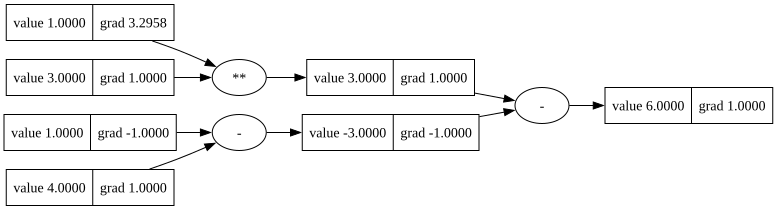

In [110]:
# d = create_random_graph(3)
d = create_random_tree(3)
# d = Expression.sum([Expression(-1), Expression(2), Expression(3)])
test_grad(d) 
backward(d)
draw_dot(d)


In [130]:
inputs = 3

def make_input():
    return [Expression(random.uniform(-3.0, 3.0)) for i in range(inputs)]
dataset = [
    make_input(),
    make_input(),
    make_input(),
]

outs = 5

def make_expect():
    return Expression(random.uniform(-outs, outs))

expects = [make_expect() for d in dataset]

brain = mlp(inputs, [outs, outs, outs])

for i in range(50):
    reached = [brain(i) for i in dataset]    
    losses = [(e - v).sqr() for v, e in zip(reached, expects)]
    loss = Expression.sum(losses)    

    print("loss: ", loss.value)

    for p in brain.parameters():
        p.grad = 0.0

    backward(loss)
    
    for p in brain.parameters():                
        p.value += -p.grad * 0.05




loss:  8.158984099068853
loss:  4.025234203011709
loss:  1.8562210743966234
loss:  1.2499152533651985
loss:  0.8460845847550474
loss:  0.5812798081201895
loss:  0.40494241500027567
loss:  0.28552705656115757
loss:  0.20325387518361515
loss:  0.14571576676374803
loss:  0.10499196656018295
loss:  0.07591231335286665
loss:  0.05501299634636304
loss:  0.03992561205715192
loss:  0.029000490866348098
loss:  0.02107386184880497
loss:  0.015315779279678577
loss:  0.011130311732077
loss:  0.0080871205647488
loss:  0.005874465653670651
loss:  0.004265930342138234
loss:  0.0030968874336675532
loss:  0.0022475242257405745
loss:  0.0016306369957416714
loss:  0.001182748628620017
loss:  0.0008576702194683012
loss:  0.0006218006184166945
loss:  0.000450708361186352
loss:  0.00032663554381536175
loss:  0.0002366813780657231
loss:  0.0001714769868383136
loss:  0.0001242214159940326
loss:  8.997930963119449e-05
loss:  6.517041822487226e-05
loss:  4.719817624674033e-05
loss:  3.417995454524003e-05
loss: 